Import Library

In [215]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import Data

In [216]:
# โหลดข้อมูล
df = pd.read_csv('cleaned_data.csv')

df_numeric = data.select_dtypes(include=['number']).copy()
# เลือก Features ที่เกี่ยวข้องกับกาแฟและชา
coffee_features = [col for col in df_numeric.columns if col.startswith('C_')]
tea_features = [col for col in df_numeric.columns if col.startswith('T_')]

# รวมรายการ Features ทั้งหมดที่ต้องการใช้ทำ Unsup
unsup_features = coffee_features + tea_features

# สร้าง DataFrame
data = df[unsup_features].copy()

# เลือกเฉพาะ Feature ที่เป็นตัวเลข
data_numeric = data.select_dtypes(include=['number']).copy()
data = data_numeric.copy()
print(f"จำนวน Features ทั้งหมดที่เลือก: {len(unsup_features)} คอลัมน์")
print(data.columns.tolist())

จำนวน Features ทั้งหมดที่เลือก: 22 คอลัมน์
['C_Fresh_Taste', 'C_Intense', 'C_Smooth', 'C_Acidic', 'C_Aroma', 'C_Alert', 'C_Origin', 'C_Portable', 'C_Value', 'C_Nutrition', 'C_Brand_Trust', 'C_Premium_Look', 'T_Aroma', 'T_Intense', 'T_No_Sugar', 'T_Zero_Cal', 'T_Nutrition', 'T_Origin', 'T_Brew_Method', 'T_Portable', 'T_Brand_Trust', 'T_Premium_Look']


In [217]:
data.info()
print('='*50)
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   C_Fresh_Taste   167 non-null    float64
 1   C_Intense       167 non-null    float64
 2   C_Smooth        167 non-null    float64
 3   C_Acidic        167 non-null    float64
 4   C_Aroma         167 non-null    float64
 5   C_Alert         167 non-null    float64
 6   C_Origin        167 non-null    float64
 7   C_Portable      167 non-null    float64
 8   C_Value         167 non-null    float64
 9   C_Nutrition     167 non-null    float64
 10  C_Brand_Trust   167 non-null    float64
 11  C_Premium_Look  167 non-null    float64
 12  T_Aroma         167 non-null    float64
 13  T_Intense       167 non-null    float64
 14  T_No_Sugar      167 non-null    float64
 15  T_Zero_Cal      167 non-null    float64
 16  T_Nutrition     167 non-null    float64
 17  T_Origin        167 non-null    flo

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Aroma,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look
0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,4.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0
1,5.0,3.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,4.0,4.0,5.0,5.0,4.0,4.0,3.0,5.0,3.0,5.0
2,1.0,1.0,5.0,1.0,2.0,5.0,1.0,2.0,2.0,2.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0
3,5.0,5.0,5.0,1.0,5.0,3.0,2.0,3.0,1.0,3.0,...,5.0,5.0,5.0,5.0,3.0,2.0,2.0,3.0,3.0,4.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,5.0,5.0,5.0,1.0,5.0,3.0,3.0,3.0,3.0,3.0


In [218]:
data.describe().round(2)

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Aroma,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,...,167.00,167.00,167.00,167.00,167.00,167.00,167.0,167.00,167.00,167.00
mean,2.89,2.63,2.77,1.71,2.86,2.59,2.14,2.78,2.45,2.40,...,3.75,3.54,3.46,3.11,3.11,2.93,2.8,3.53,3.28,3.23
std,2.12,1.98,2.06,1.55,2.09,1.97,1.76,2.05,1.96,1.87,...,1.70,1.66,1.76,1.72,1.64,1.51,1.5,1.65,1.67,1.64
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3.50,3.00,3.00,2.00,3.00,2.00,2.0,3.00,3.00,3.00
50%,4.00,3.00,4.00,1.00,4.00,3.00,3.00,4.00,3.00,3.00,...,4.00,4.00,4.00,3.00,3.00,3.00,3.0,4.00,4.00,4.00
75%,5.00,4.00,5.00,3.00,5.00,4.00,4.00,5.00,4.00,4.00,...,5.00,5.00,5.00,5.00,4.00,4.00,4.0,5.00,5.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.0,5.00,5.00,5.00


Correlation Anlysis

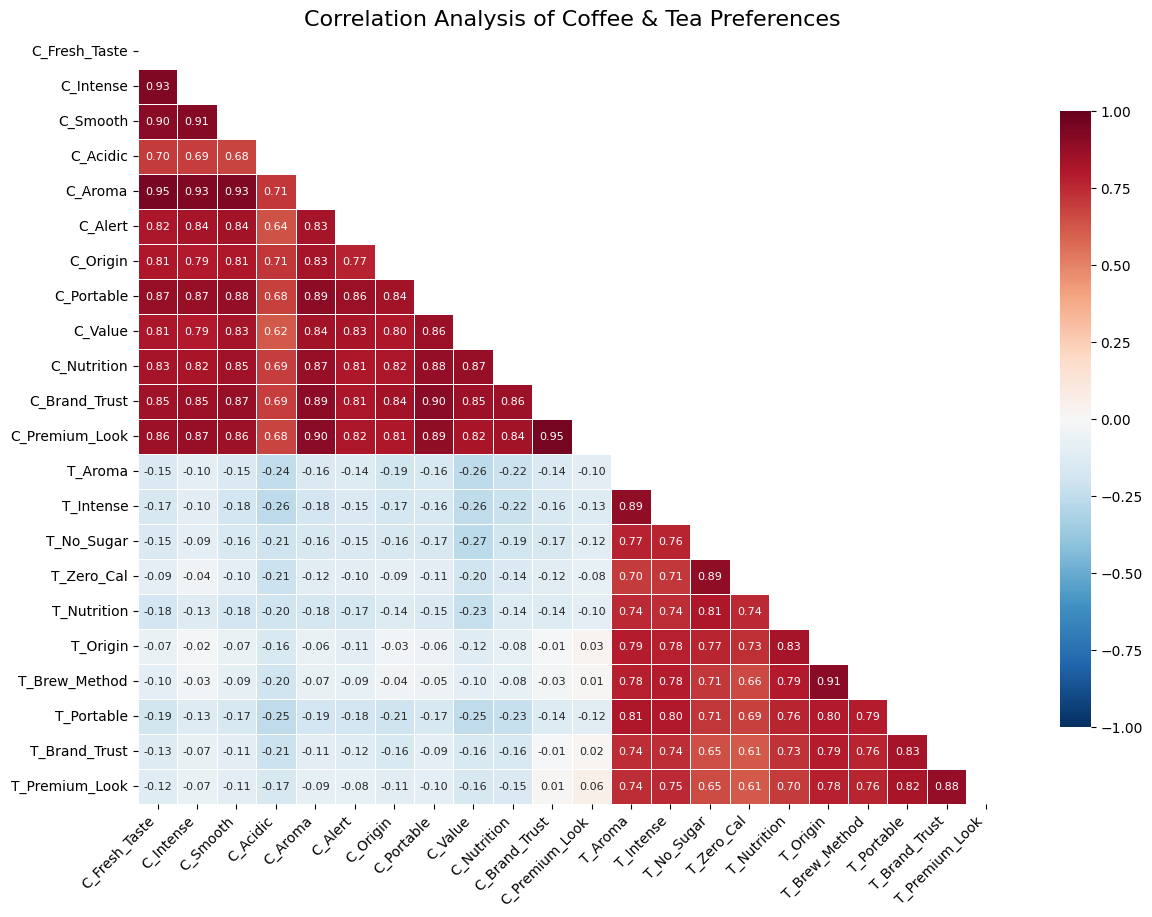

In [219]:
# คำนวณ Correlation
corr = data.corr()

# สร้าง Mask เพื่อปิดครึ่งบนไม่ให้ข้อมูลซ้ำซ้อน
mask = np.triu(np.ones_like(corr, dtype=bool))

# ตั้งค่ากราฟให้ใหญ่พอสำหรับ 20+ Features
f, ax = plt.subplots(figsize=(14, 10))

# พล็อต Heatmap
sns.heatmap(corr,
            mask=mask,
            cmap='RdBu_r',
            vmax=1, vmin=-1,
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=.5,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8})

plt.title('Correlation Analysis of Coffee & Tea Preferences', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

In [232]:
data.isnull().sum()

C_Fresh_Taste     0
C_Intense         0
C_Smooth          0
C_Acidic          0
C_Aroma           0
C_Alert           0
C_Origin          0
C_Portable        0
C_Value           0
C_Nutrition       0
C_Brand_Trust     0
C_Premium_Look    0
T_Aroma           0
T_Intense         0
T_No_Sugar        0
T_Zero_Cal        0
T_Nutrition       0
T_Origin          0
T_Brew_Method     0
T_Portable        0
T_Brand_Trust     0
T_Premium_Look    0
is_anomaly        0
dtype: int64

Feaures Scaling

In [223]:
from sklearn.preprocessing import StandardScaler

# แยกคอลัมน์ที่ไม่ต้องการสเกลออกมาเก็บไว้ก่อน
is_anomaly_col = data['is_anomaly']

# เลือกเฉพาะคอลัมน์ที่เป็น Feature (ตัวเลข 1-5) มาสเกล
features_to_scale = data.drop(columns=['is_anomaly'])

# ทำการ Scaling
scaler = StandardScaler()
scaled_array = scaler.fit_transform(features_to_scale)

# สร้าง DataFrame ใหม่จากค่าที่สเกลแล้ว
data_scaled = pd.DataFrame(scaled_array, columns=features_to_scale.columns, index=data.index)

# เอาคอลัมน์ที่แยกไว้ตอนแรกกลับไปแปะคืน
data_scaled['is_anomaly'] = is_anomaly_col

data_scaled.head()

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look,is_anomaly
0,0.053872,0.184760,0.113912,0.835079,0.066245,0.209995,0.492539,0.105274,0.282002,0.321279,...,-0.326318,0.306741,-0.066363,-0.069710,0.047816,0.136580,0.284668,-0.168883,-0.142919,0
1,1.000888,0.184760,1.089470,0.835079,0.066245,0.209995,0.492539,0.105274,0.282002,0.321279,...,0.279183,0.875915,1.100229,0.543003,0.713255,0.136580,0.894149,-0.168883,1.081058,0
2,-0.893144,-0.826878,1.089470,-0.456201,-0.414750,1.226494,-0.649878,-0.383080,-0.229893,-0.215257,...,-0.931820,-1.400782,-1.232955,-1.295136,-1.283062,-1.205121,-0.324813,-1.369034,-0.142919,0
3,1.000888,1.196399,1.089470,-0.456201,1.028234,0.209995,-0.078669,0.105274,-0.741787,0.321279,...,0.884685,0.875915,1.100229,-0.069710,-0.617623,-0.534270,-0.324813,-0.168883,0.469069,0
4,-0.893144,-0.826878,-0.861645,-0.456201,-0.895744,-0.806504,-0.649878,-0.871434,-0.741787,-0.751794,...,0.884685,0.875915,-1.232955,1.155716,0.047816,0.136580,-0.324813,-0.168883,-0.142919,0


Dimensionality Reduction (PCA)

In [224]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

print(data_pca.shape)

(167, 2)


Elbow Method for KMeans

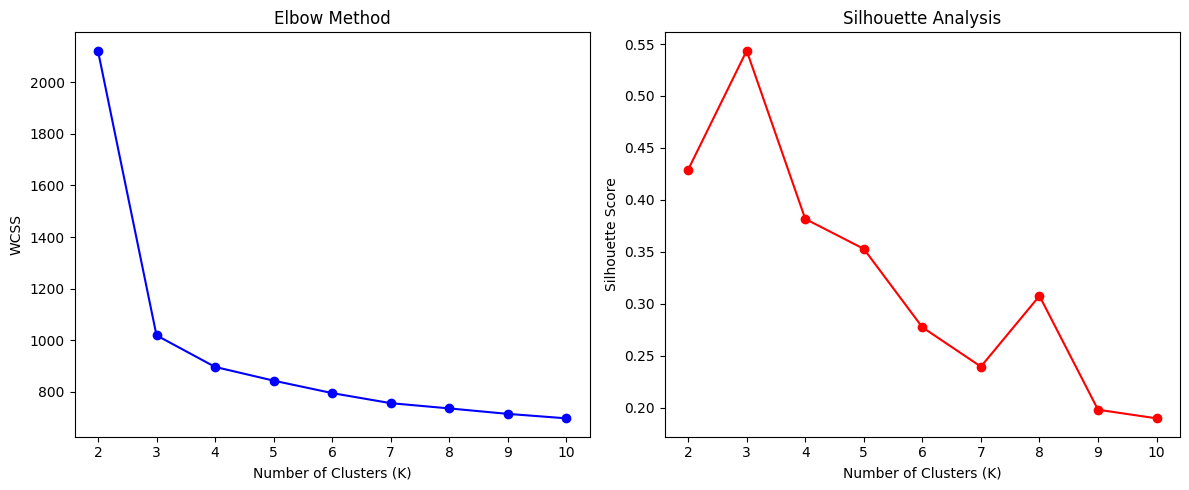

จำนวนกลุ่มที่ได้ Silhouette Score สูงสุดคือ: K = 3
ค่า Silhouette Score สูงสุด: 0.5436


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as pl

# 1. ลองรัน K-Means หลายๆ ค่า K เพื่อทำ Elbow Method
wcss = []
silhouette_avg = []
k_range = range(2, 11) # ทดสอบ K ตั้งแต่ 2 ถึง 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(data_scaled) 
    
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(data_scaled, cluster_labels))

# 2. พล็อตกราฟ Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

# 3. พล็อตกราฟ Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_avg, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.tight_layout()
plt.show()

# 4. แสดงค่าที่แม่นยำที่สุด
best_k = k_range[np.argmax(silhouette_avg)]
print(f"จำนวนกลุ่มที่ได้ Silhouette Score สูงสุดคือ: K = {best_k}")
print(f"ค่า Silhouette Score สูงสุด: {max(silhouette_avg):.4f}")

Clustering (K-Means)

In [234]:
# Fit KMeans ด้วยข้อมูลที่ไม่มี Anomaly
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(data_scaled)
clusters = kmeans.predict(data_scaled)

# Predict และเก็บค่าลงใน data_scaled
data_scaled['Cluster_ID'] = clusters

# ตรวจสอบผล
print(data_scaled['Cluster_ID'].value_counts())

Cluster_ID
1    87
2    55
0    25
Name: count, dtype: int64


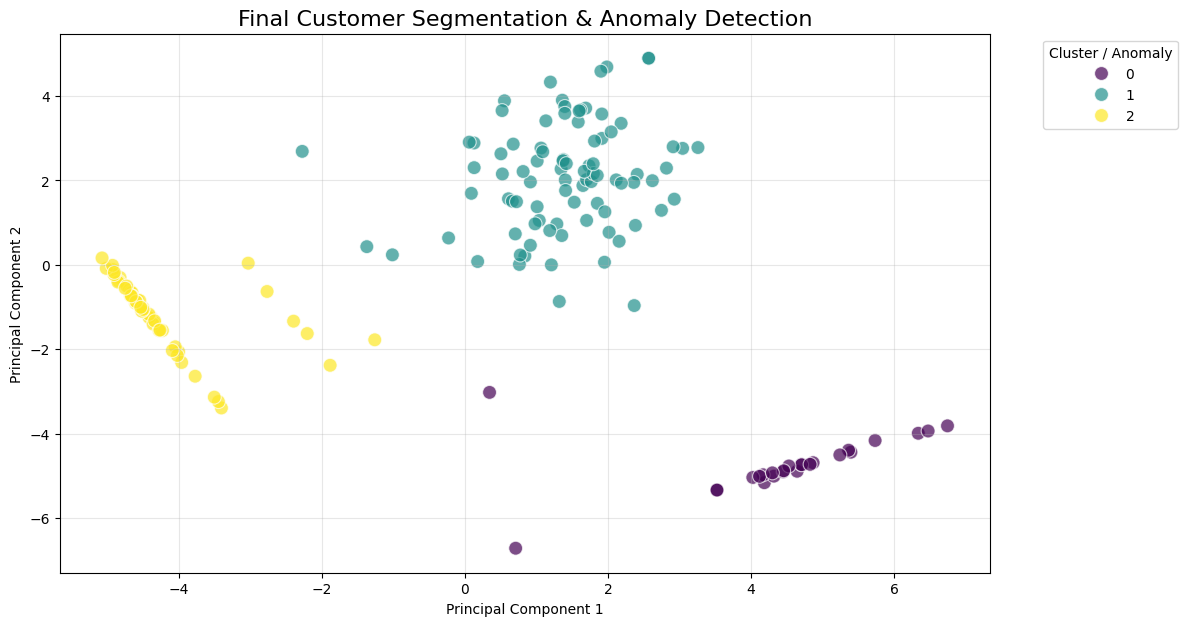

In [235]:
# สร้าง DataFrame สำหรับ Plot
df_plot = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])

# แปะ Cluster_ID ลงไป
df_plot['Cluster_ID'] = data_scaled['Cluster_ID'].values

plt.figure(figsize=(12, 7))

# ใช้ hue แยกสีตาม Cluster_ID
# และใช้ style แยกรูปร่างตาม is_anomaly
sns.scatterplot(
    data=df_plot,
    x='PC1', y='PC2',
    hue='Cluster_ID',
    palette='viridis',
    s=100,
    alpha=0.7
)

plt.title('Final Customer Segmentation & Anomaly Detection', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster / Anomaly', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

            C_Fresh_Taste  C_Intense  C_Smooth  C_Acidic   C_Aroma   C_Alert  \
Cluster_ID                                                                     
0                4.040000   3.400000  4.000000  2.800000  4.080000  3.600000   
1                4.297619   3.988095  4.071429  2.321429  4.238095  3.785714   
2                0.092593   0.092593  0.092593  0.092593  0.092593  0.166667   

            C_Origin  C_Portable   C_Value  C_Nutrition  ...   T_Aroma  \
Cluster_ID                                               ...             
0           3.200000    3.920000  3.960000     3.720000  ...  0.160000   
1           3.059524    4.107143  3.452381     3.428571  ...  4.476190   
2           0.092593    0.129630  0.092593     0.092593  ...  4.259259   

            T_Intense  T_No_Sugar  T_Zero_Cal  T_Nutrition  T_Origin  \
Cluster_ID                                                             
0            0.080000    0.040000    0.040000     0.040000  0.040000   
1           

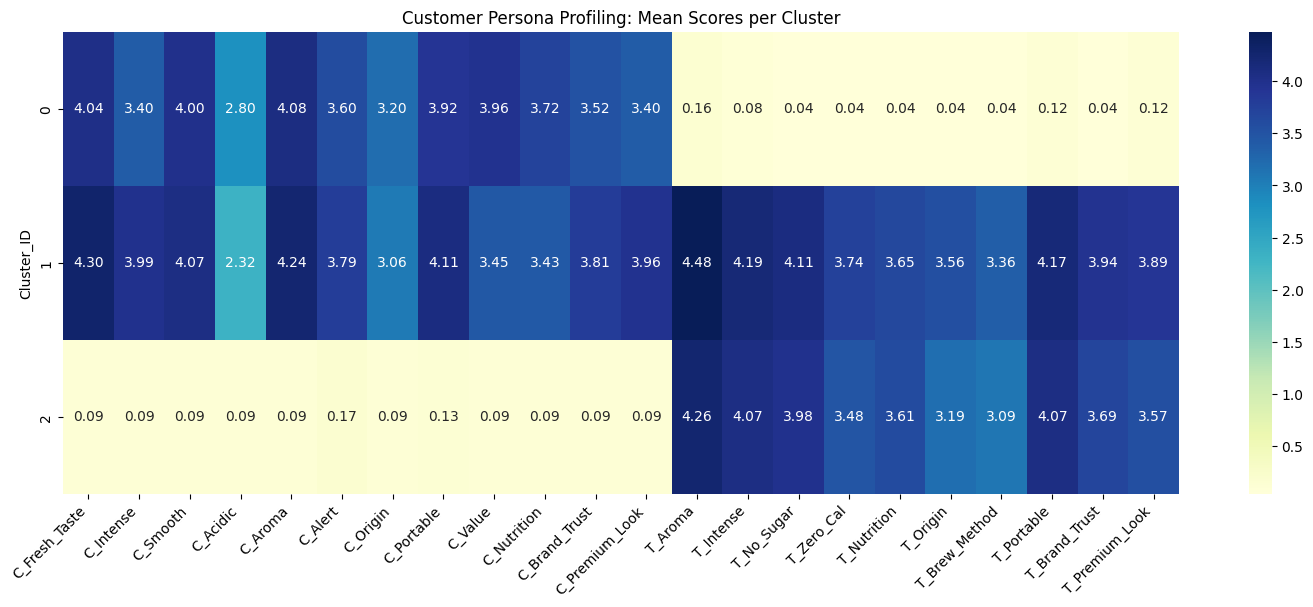

In [236]:
data['Cluster_ID'] = clusters

# กำหนด Features ที่จะใช้ทำ Profiling
feautres = [col for col in data.columns if col.startswith('C_') or col.startswith('T_')]

# คัด Anomaly ออกก่อนทำ Profiling
data_profiling = data[data['is_anomaly'] == 0]

# ทำ Profiling โดยค่าเฉลี่ยแยกตาม Cluster_ID
cluster_profile = data_profiling.groupby('Cluster_ID')[feautres].mean()
print(cluster_profile)

# แสดงผล Heatmap เพื่อวิเคราะห์จุดเด่นของแต่ละกลุ่ม
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Customer Persona Profiling: Mean Scores per Cluster')
plt.xticks(rotation=45, ha='right')
plt.show()

In [212]:
# # สร้าง row_id จาก Index เพื่อใช้เป็น Key ในการ Merge ข้อมูล
# data_scaled['row_id'] = data_scaled.index

# # เลือกเฉพาะคอลัมน์สำคัญ
# final_unsup_output = data_scaled[['row_id', 'Cluster_ID']]

# # Export ไฟล์ CSV
# final_unsup_output.to_csv('unsupervised_results.csv', index=False)
# print("Export Unsupervised Results Success!")